**Prédiction de congestion routière — HubertApp**

Friction : Cela correspond à l'effet qui cause les ralentissement et les congestions, plus il y a de friction sur un edge plus cela risque de causé un ralentissement voir une congestion.

L'objectif de notre modèle est de prédire un coefficient de friction par zone géographique et par
heure, à partir du calendrier et de la météo.

Une friction = 1.0 c'est à dire que la circulation est fluide. Une friction = 1.5 signifie donc qu'il faut 50 % de temps en plus.

A terme on voudrait que ce coefficient soit ensuite consommé par le moteur d'itinéraire pour pondérer les routes, mais surtout qu'ils suvivent le trajet et envoie une notification à rabbitmq pour recalculer le graph via ce même coefficient.


Pour l'entrainement du modèle, ont utilise des données réel récupérer via notre micro-service de collecte (python -m app.cli export), sous forme d'archive observations_*.zip.

Nous nous sommes volontairement stopper à l'étape du simple machine learnig via scikit-learn et une simple regression basé sur arbre de décision HistGradientBoostingRegressor. L'idéal aurait était en effet de construire notre propre modèle via Tensorflow via keras, mais nous n'avons pas eu le temps.

Import des lib

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob, zipfile, json

In [6]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import learning_curve

In [7]:
from sklearn.metrics import (mean_absolute_error, root_mean_squared_error, r2_score,
                             classification_report, ConfusionMatrixDisplay)

**Chargement des données**

In [8]:
archives = sorted(glob.glob("/content/sample_data/observations_*.zip"))
if not archives:
    raise FileNotFoundError(
        "Aucune archive observations_*.zip. Téléversez-la via le panneau Fichiers. "
        "Elle se produit côté service avec :  python -m app.cli export")

with zipfile.ZipFile(archives[-1]) as zf:
    zf.extractall(".")

df = pd.read_csv("observations.csv")
df["moment"] = pd.to_datetime(df["observed_at"], utc=True, format="mixed")
manifeste = json.load(open("manifest.json"))

print(f"Archive : {archives[-1]}")
print(f"lignes : {manifeste['lignes']}")
print(f"tuiles : {len(manifeste['tuiles'])}")
print(f"période : du {manifeste['periode']['debut'][:10]} au {manifeste['periode']['fin'][:10]}")
print(f"sources : {manifeste['sources']}")
print(f"features.py extrait : {__import__('os').path.exists('features.py')}")

Archive : /content/sample_data/observations_20260914.zip
lignes : 12096
tuiles : 9
période : du 2026-07-19 au 2026-09-13
sources : {'backfill': 12096}
features.py extrait : True


Vérification de version

In [9]:
!pip install -q scikit-learn==1.8.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 37.1 MB/s eta 0:00:00


In [10]:
import sklearn

attendue = manifeste["sklearn_cible"]
if sklearn.__version__ != attendue:
    print(f"ATTENTION : Colab a scikit-learn {sklearn.__version__}, le service attend {attendue}.")
    print(f"!pip install -q scikit-learn=={attendue}")

ATTENTION : Colab a scikit-learn 1.6.1, le service attend 1.8.0.
!pip install -q scikit-learn==1.8.0


**Vérification de la structure des données**

In [11]:
print(df.shape); print(); print(df.dtypes)
df.head()

(12096, 9)

observed_at                       object
tile_id                           object
friction                         float64
is_public_holiday                   bool
precipitation_mm                 float64
source                            object
temperature_c                    float64
wind_speed_kmh                   float64
moment               datetime64[ns, UTC]
dtype: object


,observed_at,tile_id,friction,is_public_holiday,precipitation_mm,source,temperature_c,wind_speed_kmh,moment
0,2026-07-19T22:00:00+00:00,50.99:2.31,1.190,False,2.84,backfill,17.8,13.8,2026-07-19 22:00:00+00:00
1,2026-07-19T22:00:00+00:00,50.99:2.37,1.033,False,2.84,backfill,17.8,13.8,2026-07-19 22:00:00+00:00
2,2026-07-19T22:00:00+00:00,50.99:2.43,1.066,False,2.84,backfill,17.8,13.8,2026-07-19 22:00:00+00:00
3,2026-07-19T22:00:00+00:00,51.02:2.31,1.050,False,2.84,backfill,17.8,13.8,2026-07-19 22:00:00+00:00
4,2026-07-19T22:00:00+00:00,51.02:2.37,1.200,False,2.84,backfill,17.8,13.8,2026-07-19 22:00:00+00:00


In [12]:
print(f"Période : du {df['moment'].min():%Y-%m-%d} au {df['moment'].max():%Y-%m-%d}")
print(f"Tuiles  : {df['tile_id'].nunique()}")
print("\nValeurs manquantes :")
print(df.isna().sum())

Période : du 2026-07-19 au 2026-09-13
Tuiles  : 9

Valeurs manquantes :
observed_at          0
tile_id              0
friction             0
is_public_holiday    0
precipitation_mm     0
source               0
temperature_c        0
wind_speed_kmh       0
moment               0
dtype: int64


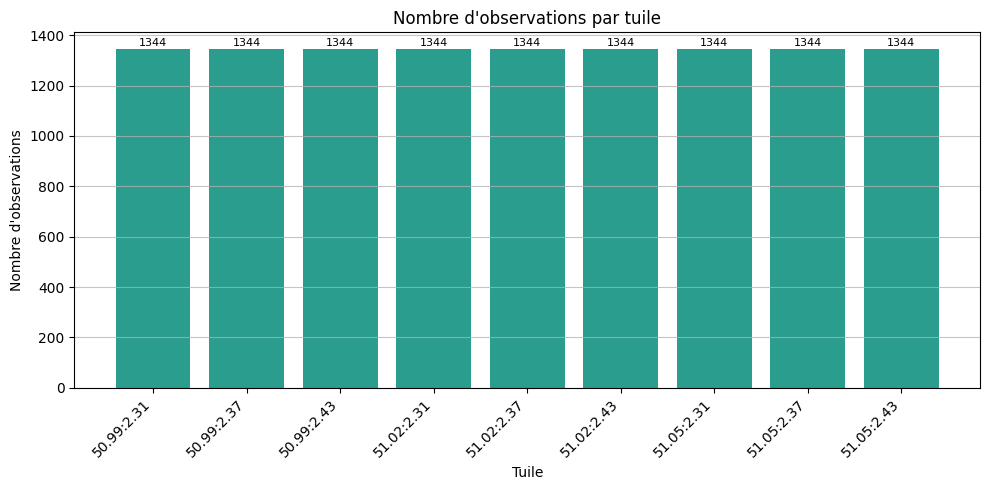

In [13]:
par_tuile = df["tile_id"].value_counts().sort_index()

plt.figure(figsize=(10, 5))
plt.bar(par_tuile.index, par_tuile.values, color='#2a9d8f')
plt.title("Nombre d'observations par tuile")
plt.xlabel("Tuile"); plt.ylabel("Nombre d'observations")
plt.xticks(rotation=45, ha='right'); plt.grid(axis='y', alpha=0.75)
for i, v in enumerate(par_tuile.values):
    plt.text(i, v + max(par_tuile.values)*0.01, str(v), ha='center', fontsize=8)
plt.tight_layout(); plt.show()

Les tuiles sont équilibrées : le collecteur interroge chaque point au même
rythme.

**Analyse des données**

Profil de congestion sur la journée

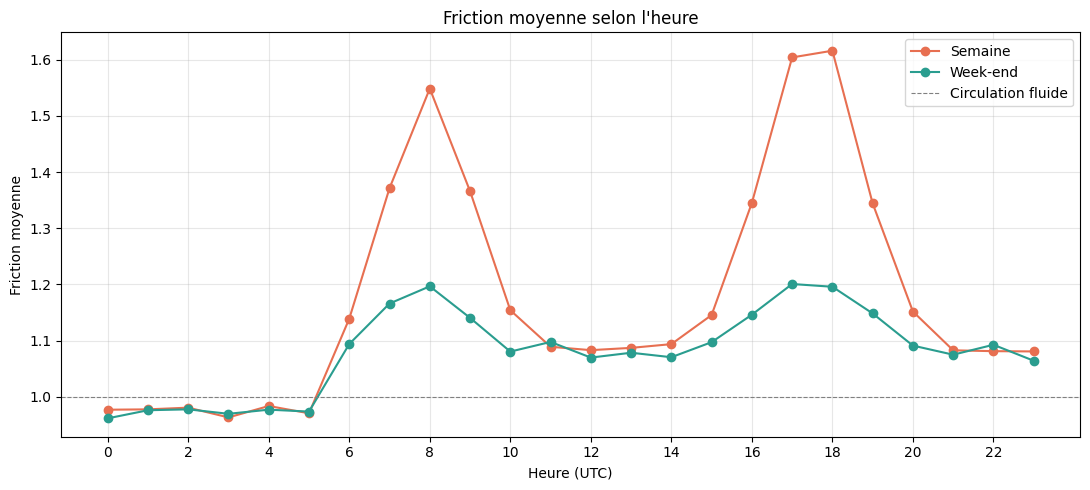

In [14]:
df["heure"]   = df["moment"].dt.hour
df["jour"]    = df["moment"].dt.dayofweek
df["weekend"] = df["jour"] >= 5

profil = df.groupby(["heure", "weekend"])["friction"].mean().unstack()

plt.figure(figsize=(11, 5))
plt.plot(profil.index, profil[False], marker='o', color='#e76f51', label='Semaine')
plt.plot(profil.index, profil[True],  marker='o', color='#2a9d8f', label='Week-end')
plt.axhline(1.0, color='grey', ls='--', lw=0.8, label='Circulation fluide')
plt.title("Friction moyenne selon l'heure")
plt.xlabel("Heure (UTC)"); plt.ylabel("Friction moyenne")
plt.xticks(range(0, 24, 2)); plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

C'est le graphique le plus important : il montre le signal que le modèle doit
apprendre. Comme ont s'y attendaient déjà, on a deux pointes en semaine, vers 8 h et vers 17 h 30, très amorties le
week-end. Si les deux courbes se superposaient, aucun modèle ne pourrait rien
tirer de ces données.

Comportement par tuile

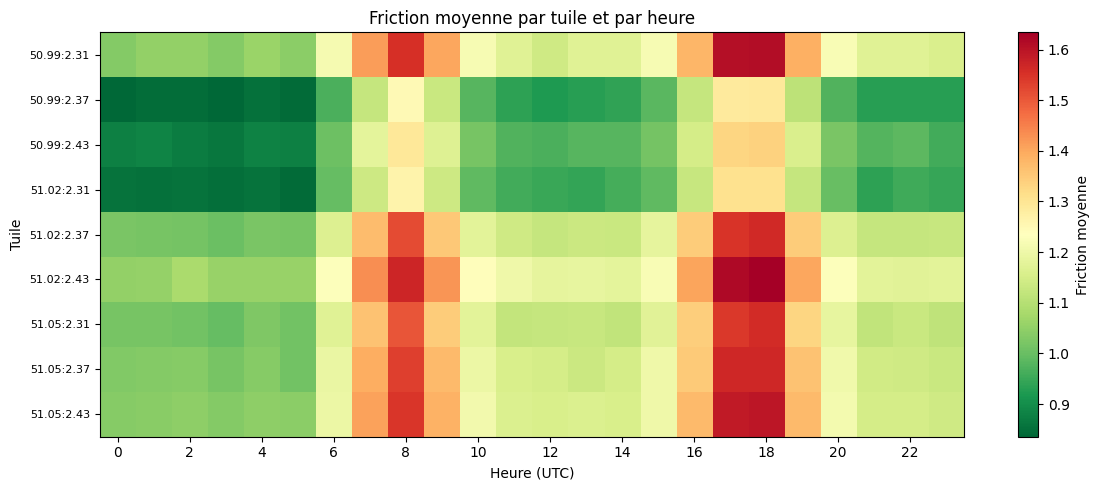

In [15]:
grille = df.pivot_table(index="tile_id", columns="heure", values="friction", aggfunc="mean")

plt.figure(figsize=(12, 5))
plt.imshow(grille.values, aspect='auto', cmap='RdYlGn_r')
plt.colorbar(label="Friction moyenne")
plt.yticks(range(len(grille.index)), grille.index, fontsize=8)
plt.xticks(range(0, 24, 2), range(0, 24, 2))
plt.title("Friction moyenne par tuile et par heure")
plt.xlabel("Heure (UTC)"); plt.ylabel("Tuile")
plt.tight_layout(); plt.show()

Les lignes ne sont pas identiques : certaines tuiles sont structurellement plus
chargées. La variable tile_id porte donc de l'information et doit être donnée
au modèle.

Effet des jours fériés

Le collecteur écrit déjà is_public_holiday dans chaque observation. On
vérifie que la variable sépare réellement quelque chose, si les deux barres sont
identiques, elle ne sert à rien.

                     mean  count
is_public_holiday               
False              1.1507  11880
True               1.0778    216


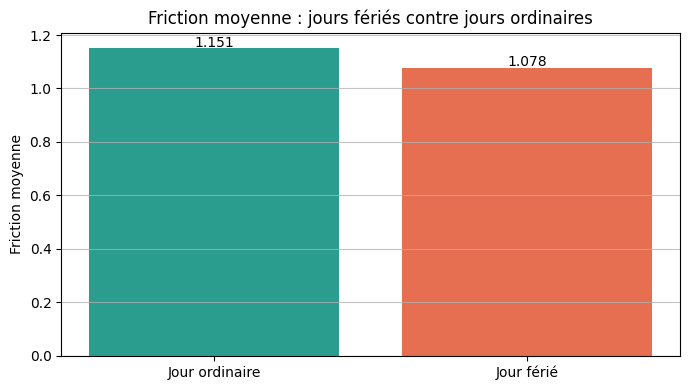

In [16]:
ferie = df.groupby("is_public_holiday")["friction"].agg(["mean", "count"])
print(ferie.round(4))

if len(ferie) > 1:
    plt.figure(figsize=(7, 4))
    plt.bar(["Jour ordinaire", "Jour férié"], ferie["mean"].values,
            color=['#2a9d8f', '#e76f51'])
    plt.title("Friction moyenne : jours fériés contre jours ordinaires")
    plt.ylabel("Friction moyenne"); plt.grid(axis='y', alpha=0.75)
    for i, v in enumerate(ferie["mean"].values):
        plt.text(i, v + 0.005, f"{v:.3f}", ha='center')
    plt.tight_layout(); plt.show()
else:
    print("\nAucun jour férié sur la période : la variable sera sans effet ici.")
    print("C'est normal sur 8 semaines d'été. Elle servira sur un historique plus long.")

**Vérification de la qualité de la cible**

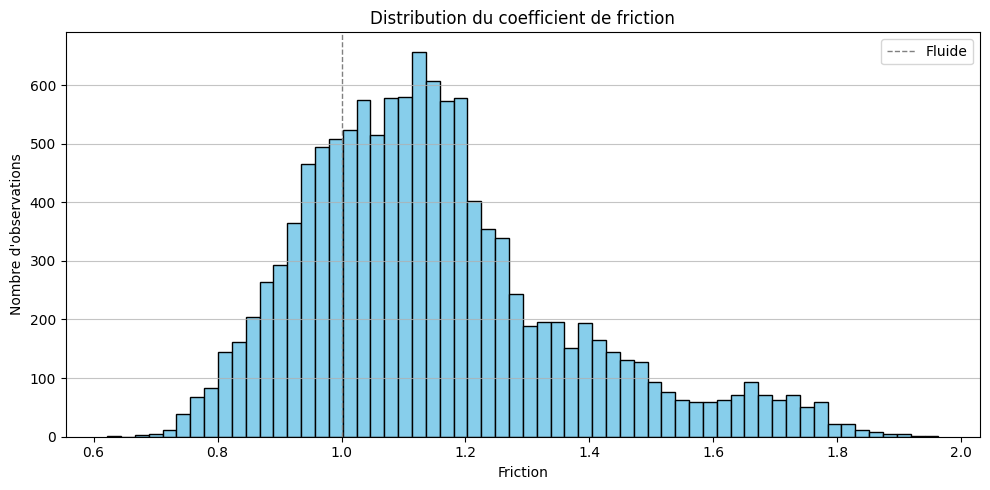

count    12096.000
mean         1.149
std          0.216
min          0.622
25%          0.998
50%          1.120
75%          1.249
max          1.963
Name: friction, dtype: float64


In [17]:
plt.figure(figsize=(10, 5))
plt.hist(df["friction"], bins=60, color='skyblue', edgecolor='black')
plt.axvline(1.0, color='grey', ls='--', lw=1, label='Fluide')
plt.title("Distribution du coefficient de friction")
plt.xlabel("Friction"); plt.ylabel("Nombre d'observations")
plt.legend(); plt.grid(axis='y', alpha=0.75)
plt.tight_layout(); plt.show()

print(df["friction"].describe().round(3))

Variance par tuile

Une tuile dont la friction ne bouge jamais n'apprend rien au modèle : elle
apporte une valeur constante que la moyenne prédirait aussi bien.

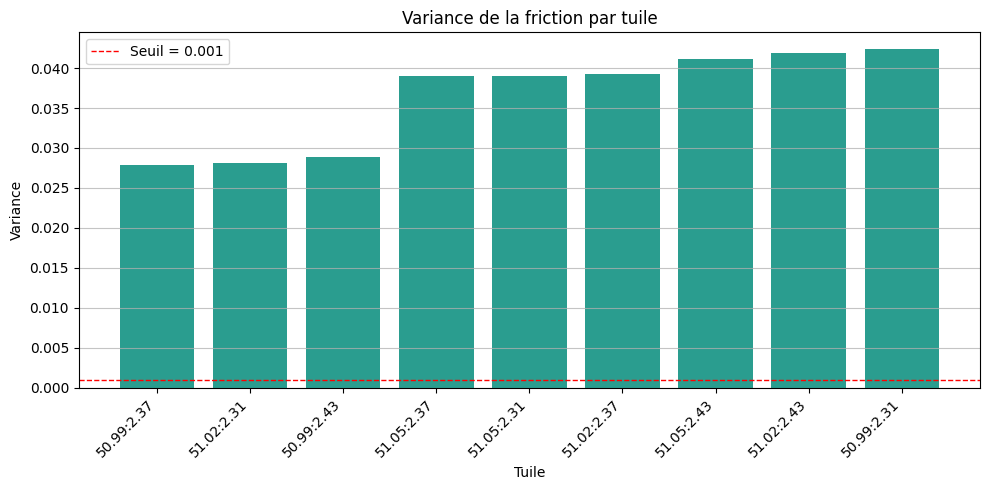

Tuiles sous le seuil : aucune
12096 observations conservées


In [18]:
variance = df.groupby("tile_id")["friction"].var().sort_values()
SEUIL_VARIANCE = 0.001
couleurs = ['#e76f51' if v < SEUIL_VARIANCE else '#2a9d8f' for v in variance.values]

plt.figure(figsize=(10, 5))
plt.bar(variance.index, variance.values, color=couleurs)
plt.axhline(SEUIL_VARIANCE, color='red', ls='--', lw=1, label=f'Seuil = {SEUIL_VARIANCE}')
plt.title("Variance de la friction par tuile")
plt.xlabel("Tuile"); plt.ylabel("Variance")
plt.xticks(rotation=45, ha='right'); plt.legend(); plt.grid(axis='y', alpha=0.75)
plt.tight_layout(); plt.show()

a_retirer = variance[variance < SEUIL_VARIANCE].index.tolist()
print(f"Tuiles sous le seuil : {a_retirer if a_retirer else 'aucune'}")
df = df[~df["tile_id"].isin(a_retirer)].reset_index(drop=True)
print(f"{len(df)} observations conservées")

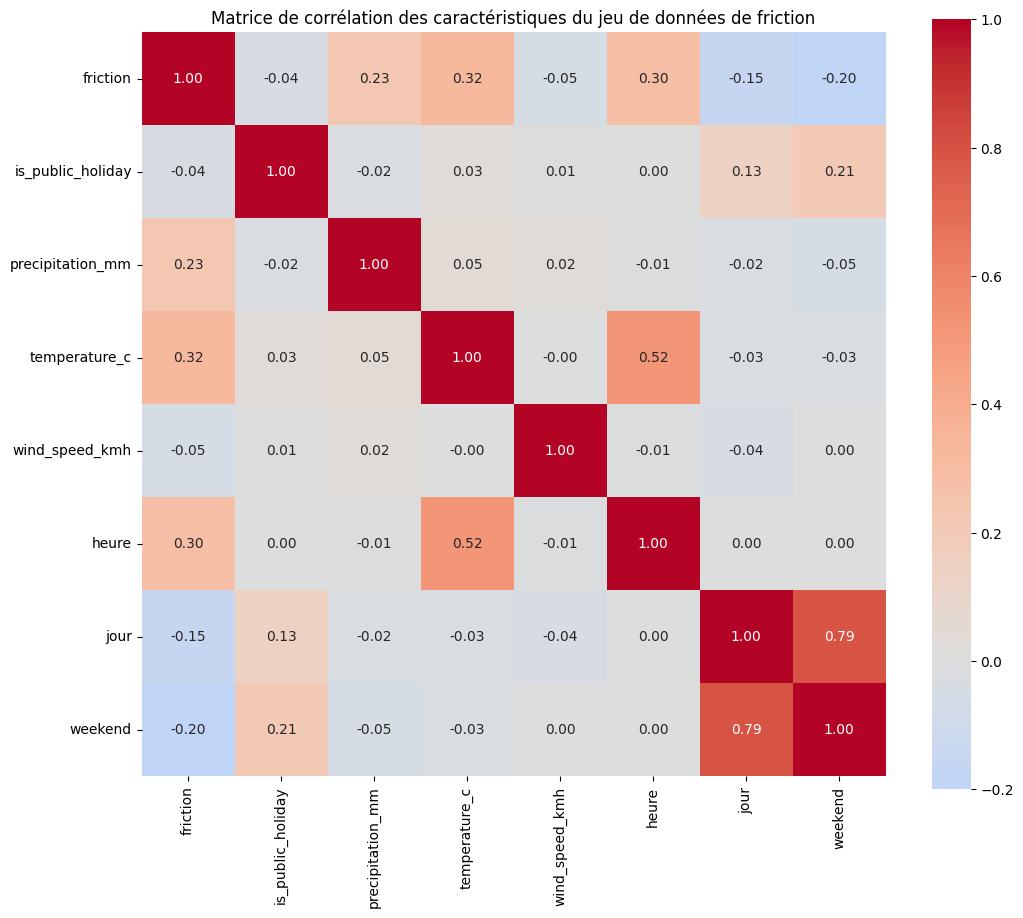

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number', 'bool'])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, fmt=".2f")
plt.title("Matrice de corrélation des caractéristiques du jeu de données de friction")
plt.show()

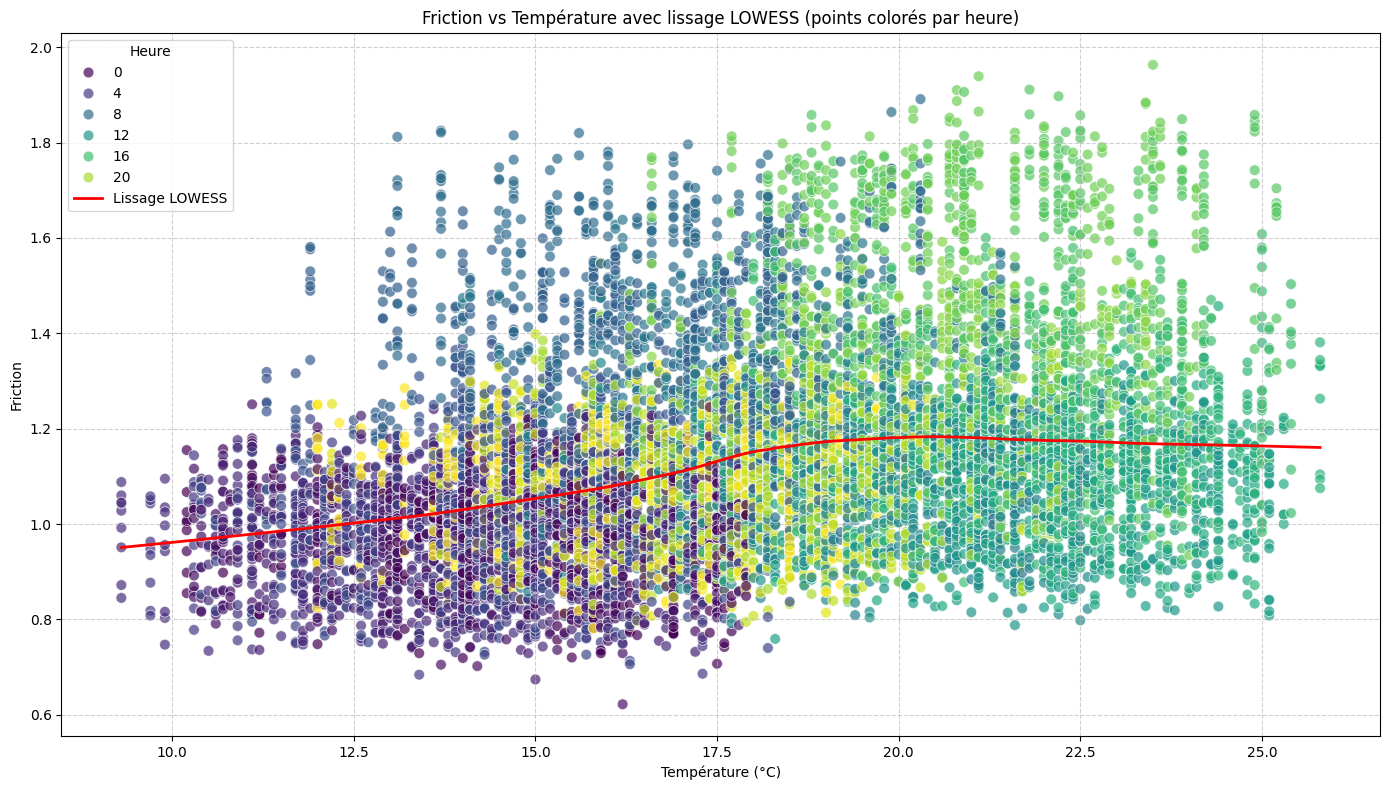

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

df_sorted = df.sort_values(by='temperature_c')

plt.figure(figsize=(14, 8))

sns.scatterplot(
    x='temperature_c',
    y='friction',
    hue='heure',
    data=df_sorted,
    palette='viridis',
    s=60,
    alpha=0.7
)

lowess_smoothed = sm.nonparametric.lowess(df_sorted['friction'], df_sorted['temperature_c'], frac=0.3)

plt.plot(lowess_smoothed[:, 0], lowess_smoothed[:, 1], color='red', linestyle='-', linewidth=2, label='Lissage LOWESS', zorder=5)

plt.title('Friction vs Température avec lissage LOWESS (points colorés par heure)')
plt.xlabel('Température (°C)')
plt.ylabel('Friction')
plt.legend(title='Heure')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_961/1075901972.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='precipitation_category', y='friction', data=df, palette='viridis', order=labels)


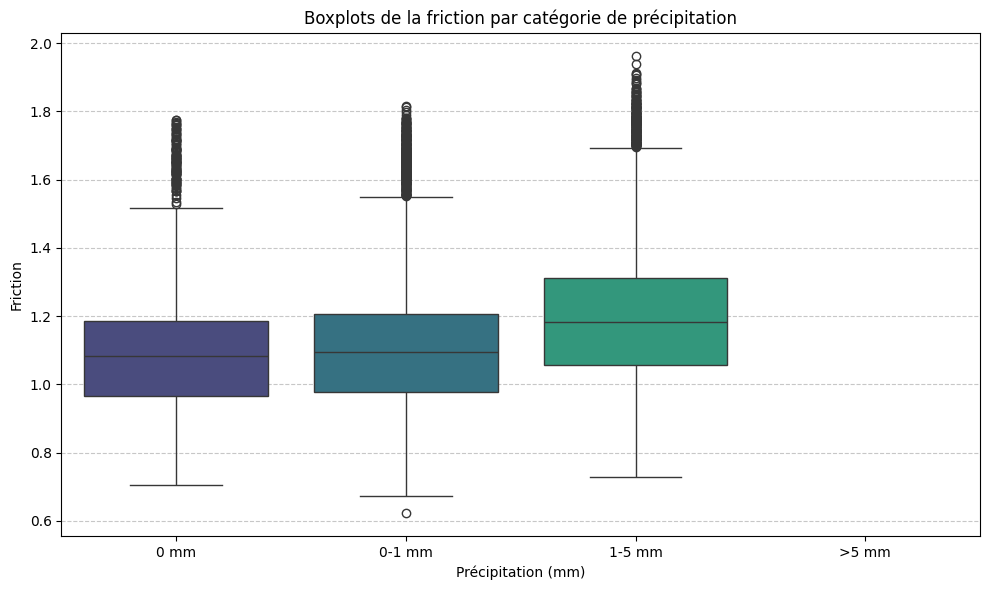

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

bins = [-np.inf, 0.001, 1.0, 5.0, np.inf]
labels = ['0 mm', '0-1 mm', '1-5 mm', '>5 mm']

df['precipitation_category'] = pd.cut(df['precipitation_mm'], bins=bins, labels=labels, right=False)

df.loc[df['precipitation_mm'] == 0, 'precipitation_category'] = '0 mm'

plt.figure(figsize=(10, 6))
sns.boxplot(x='precipitation_category', y='friction', data=df, palette='viridis', order=labels)

plt.title('Boxplots de la friction par catégorie de précipitation')
plt.xlabel('Précipitation (mm)')
plt.ylabel('Friction')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Séparation entraînement / validation**

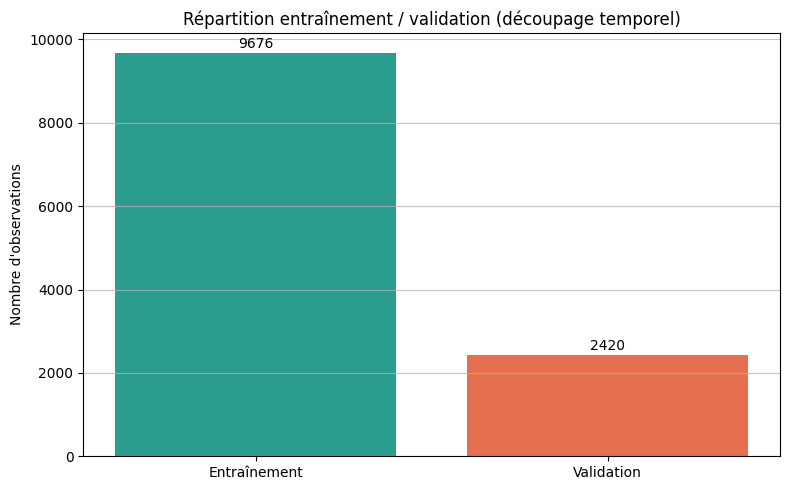

Entraînement : 2026-07-19 -> 2026-09-02
Validation   : 2026-09-02 -> 2026-09-13


In [22]:
df = df.sort_values("moment").reset_index(drop=True)
coupure = int(len(df) * 0.8)
train_df, val_df = df.iloc[:coupure], df.iloc[coupure:]

plt.figure(figsize=(8, 5))
plt.bar(["Entraînement", "Validation"], [len(train_df), len(val_df)],
        color=['#2a9d8f', '#e76f51'])
plt.title("Répartition entraînement / validation (découpage temporel)")
plt.ylabel("Nombre d'observations"); plt.grid(axis='y', alpha=0.75)
for i, n in enumerate([len(train_df), len(val_df)]):
    plt.text(i, n + len(df)*0.01, str(n), ha='center')
plt.tight_layout(); plt.show()

print(f"Entraînement : {train_df['moment'].min():%Y-%m-%d} -> {train_df['moment'].max():%Y-%m-%d}")
print(f"Validation   : {val_df['moment'].min():%Y-%m-%d} -> {val_df['moment'].max():%Y-%m-%d}")

**Préparation des variables**

identique à features.py coté prod

Encodage sinus / cosinus de l'heure et du jour, sans quoi le
modèle verrait 23 h et 0 h comme les deux extrémités d'une échelle alors qu'il
n'y a qu'une heure entre les deux ; lecture de is_public_holiday depuis les
données plutôt que recalcul ; et tile_id laissé en catégorie.


In [23]:
from features import prepare, VARIABLES

X_train, y_train = prepare(train_df), train_df["friction"]
X_val,   y_val   = prepare(val_df),   val_df["friction"]

print("Variables :", VARIABLES)
print(X_train.shape, X_val.shape)
X_train.head(3)

Variables : ['hour_sin', 'hour_cos', 'dow_sin', 'dow_cos', 'is_weekend', 'is_public_holiday', 'temperature_c', 'precipitation_mm', 'wind_speed_kmh', 'tile_id']
(9676, 10) (2420, 10)


,hour_sin,hour_cos,dow_sin,dow_cos,is_weekend,is_public_holiday,temperature_c,precipitation_mm,wind_speed_kmh,tile_id
0,-0.5,0.866025,-0.781831,0.62349,1,0,17.8,2.84,13.8,50.99:2.31
1,-0.5,0.866025,-0.781831,0.62349,1,0,17.8,2.84,13.8,50.99:2.37
2,-0.5,0.866025,-0.781831,0.62349,1,0,17.8,2.84,13.8,50.99:2.43


**Création du modèle**

In [24]:
modele = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.08,
    max_depth=6,
    categorical_features=["tile_id"],
    early_stopping=True,
    random_state=42,
)
modele

HistGradientBoostingRegressor(categorical_features=['tile_id'],
                              early_stopping=True, learning_rate=0.08,
                              max_depth=6, max_iter=300, random_state=42)

**Lancement du modèle**

In [25]:
modele.fit(X_train, y_train)
print("Entraînement terminé")

Entraînement terminé


Informations du modèle

In [26]:
print(f"Arbres effectivement construits : {modele.n_iter_} (plafond : {modele.max_iter})")
print(f"Arrêt anticipé déclenché        : {modele.n_iter_ < modele.max_iter}")
print(f"Variables utilisées             : {modele.n_features_in_}")

Arbres effectivement construits : 81 (plafond : 300)
Arrêt anticipé déclenché        : True
Variables utilisées             : 10


**Analyse des résultats**

In [27]:
y_pred = modele.predict(X_val)

# Référence : médiane historique par (tuile, jour, heure). Étalon, pas un modèle.
table = train_df.groupby(["tile_id", "jour", "heure"])["friction"].median()
globale = train_df["friction"].median()
y_ref = np.array([table.get((t, j, h), globale)
                  for t, j, h in zip(val_df["tile_id"], val_df["jour"], val_df["heure"])])

print(f"{'':<22}{'MAE':>10}{'RMSE':>10}{'R2':>10}")
print("-" * 52)
for nom, p in [("Référence (médiane)", y_ref), ("Modèle", y_pred)]:
    print(f"{nom:<22}{mean_absolute_error(y_val, p):>10.4f}"
          f"{root_mean_squared_error(y_val, p):>10.4f}{r2_score(y_val, p):>10.4f}")

gain = (mean_absolute_error(y_val, y_ref) - mean_absolute_error(y_val, y_pred)) \
       / mean_absolute_error(y_val, y_ref) * 100
print(f"\nGain du modèle sur la référence : {gain:.1f} %")

                             MAE      RMSE        R2
----------------------------------------------------
Référence (médiane)       0.0589    0.0737    0.8797
Modèle                    0.0417    0.0519    0.9403

Gain du modèle sur la référence : 29.3 %


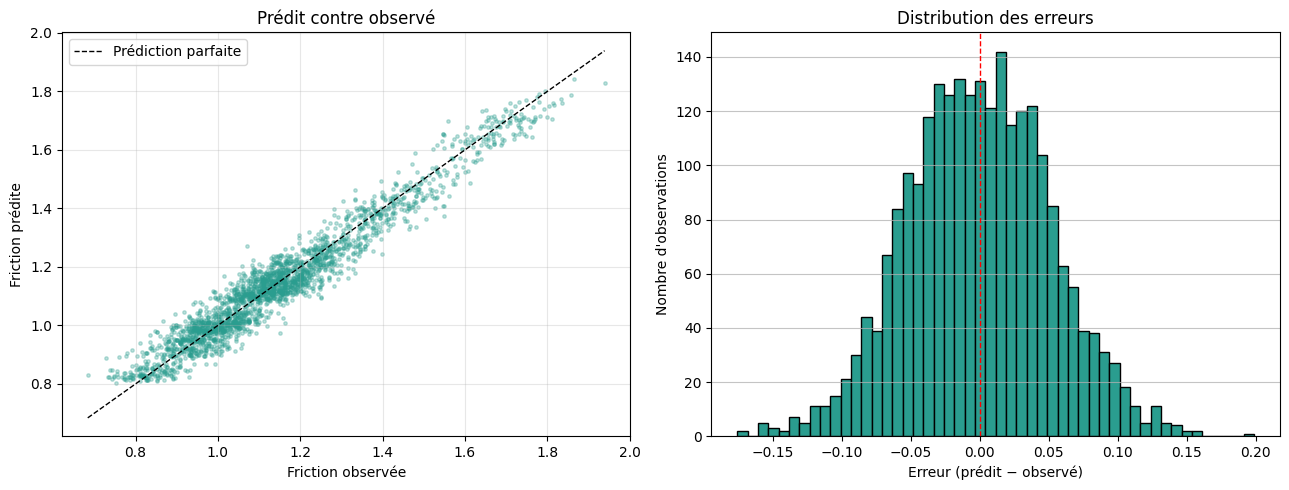

In [28]:
fig, (g, d) = plt.subplots(1, 2, figsize=(13, 5))

g.scatter(y_val, y_pred, s=6, alpha=0.3, color='#2a9d8f')
lim = [y_val.min(), y_val.max()]
g.plot(lim, lim, 'k--', lw=1, label='Prédiction parfaite')
g.set_xlabel("Friction observée"); g.set_ylabel("Friction prédite")
g.set_title("Prédit contre observé"); g.legend(); g.grid(alpha=0.3)

d.hist(y_pred - y_val, bins=50, color='#2a9d8f', edgecolor='black')
d.axvline(0, color='red', ls='--', lw=1)
d.set_xlabel("Erreur (prédit − observé)"); d.set_ylabel("Nombre d'observations")
d.set_title("Distribution des erreurs"); d.grid(axis='y', alpha=0.75)

plt.tight_layout(); plt.show()

Le nuage se resserre autour de la diagonale et les erreurs se répartissent
symétriquement autour de zéro : le modèle ne surestime ni ne sous-estime
systématiquement.

**Matrice de confusion par niveau de congestion**

Le modèle est une régression, mais l'application n'affiche que trois niveaux
dans le fil des perturbations. On découpe donc les valeurs pour inspecter les
résultats comme une classification :

- Fluide : friction < 1,15
- Ralenti : de 1,15 à 1,40
- Congestionné : au-delà de 1,40


              precision    recall  f1-score   support

Congestionné       0.93      0.89      0.91       289
      Fluide       0.90      0.90      0.90      1431
     Ralenti       0.75      0.76      0.75       700

    accuracy                           0.86      2420
   macro avg       0.86      0.85      0.85      2420
weighted avg       0.86      0.86      0.86      2420



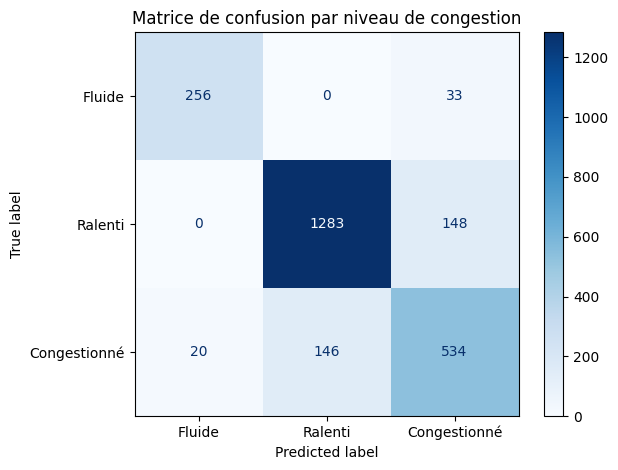

In [29]:
NIVEAUX = ["Fluide", "Ralenti", "Congestionné"]
BORNES  = [-np.inf, 1.15, 1.40, np.inf]

vrai   = pd.cut(y_val,  bins=BORNES, labels=NIVEAUX)
predit = pd.cut(y_pred, bins=BORNES, labels=NIVEAUX)

print(classification_report(vrai, predit, zero_division=0))

ConfusionMatrixDisplay.from_predictions(vrai, predit, display_labels=NIVEAUX,
                                        cmap="Blues", values_format="d")
plt.title("Matrice de confusion par niveau de congestion")
plt.tight_layout(); plt.show()

Les erreurs doivent rester sur les cases adjacentes à la diagonale. Confondre
« Fluide » et « Ralenti » coûte quelques secondes d'itinéraire ; confondre
« Fluide » et « Congestionné » enverrait l'utilisateur dans un bouchon.

**Courbe d'apprentissage**

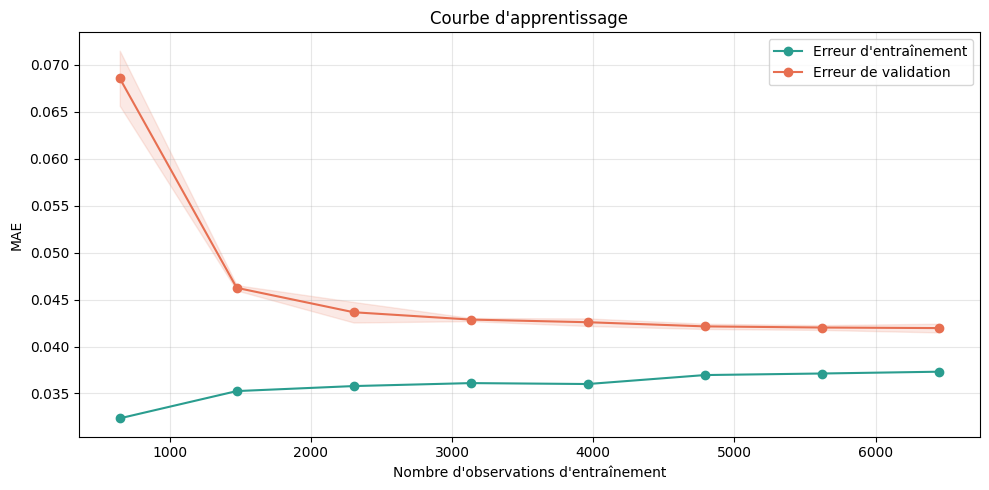

In [30]:
tailles, score_train, score_val = learning_curve(
    HistGradientBoostingRegressor(max_iter=300, learning_rate=0.08, max_depth=6,
                                  categorical_features=["tile_id"],
                                  early_stopping=True, random_state=42),
    X_train, y_train,
    train_sizes=np.linspace(0.1, 1.0, 8),
    cv=3, scoring="neg_mean_absolute_error", shuffle=False)

plt.figure(figsize=(10, 5))
plt.plot(tailles, -score_train.mean(axis=1), marker='o', color='#2a9d8f',
         label="Erreur d'entraînement")
plt.plot(tailles, -score_val.mean(axis=1), marker='o', color='#e76f51',
         label="Erreur de validation")
plt.fill_between(tailles, -score_val.mean(axis=1) - score_val.std(axis=1),
                 -score_val.mean(axis=1) + score_val.std(axis=1),
                 alpha=0.15, color='#e76f51')
plt.title("Courbe d'apprentissage")
plt.xlabel("Nombre d'observations d'entraînement"); plt.ylabel("MAE")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

**Importance des variables**

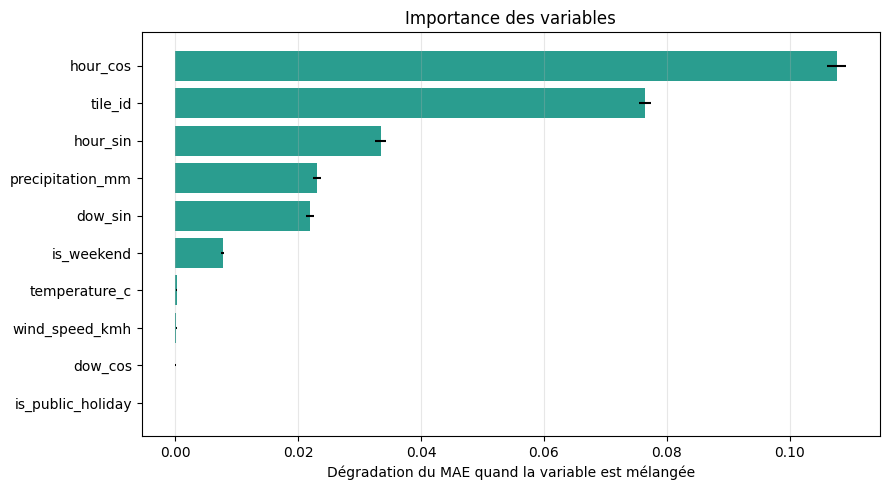

In [31]:
imp = permutation_importance(modele, X_val, y_val, n_repeats=5,
                            random_state=42, scoring="neg_mean_absolute_error")
ordre = np.argsort(imp.importances_mean)

plt.figure(figsize=(9, 5))
plt.barh([VARIABLES[i] for i in ordre], imp.importances_mean[ordre],
         xerr=imp.importances_std[ordre], color='#2a9d8f')
plt.title("Importance des variables")
plt.xlabel("Dégradation du MAE quand la variable est mélangée")
plt.grid(axis='x', alpha=0.3)
plt.tight_layout(); plt.show()

**Export du modèle vers le service**

In [32]:
import joblib

table_ref = train_df.groupby(["tile_id", "jour", "heure"])["friction"].median()

bundle = {
    "modele": modele,
    "variables": VARIABLES,
    "tuiles": sorted(train_df["tile_id"].unique()),
    "reference": {"table": {f"{t}|{j}|{h}": float(v) for (t, j, h), v in table_ref.items()},
                  "globale": float(train_df["friction"].median())},
    "sklearn": sklearn.__version__,
}

joblib.dump(bundle, "friction.joblib")
print("friction.joblib écrit")
print(f"  tuiles connues : {len(bundle['tuiles'])}")
print(f"  variables      : {len(bundle['variables'])}")
print(f"  scikit-learn   : {bundle['sklearn']}")

friction.joblib écrit
  tuiles connues : 9
  variables      : 10
  scikit-learn   : 1.6.1


In [33]:
try:
    from google.colab import files
    files.download("friction.joblib")
except ImportError:
    print("Hors Colab : le fichier est dans le dossier courant.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

On constate que la matrice de corrélation nous aide à determiner que des variables permettent de prédire la friction et la matrice de confusion montre que le modèle reconnait tout de même bien les pattern avec une diagonal suffisament prononcer pour prouver que le modèle puissent servir

La météo pèse moins que le calendrier, mais elle n'est pas négligeable, la température n'est pas le facteur le plus déterminant, c'est les précipitation comme ont pouvait s'y attendre.